## API
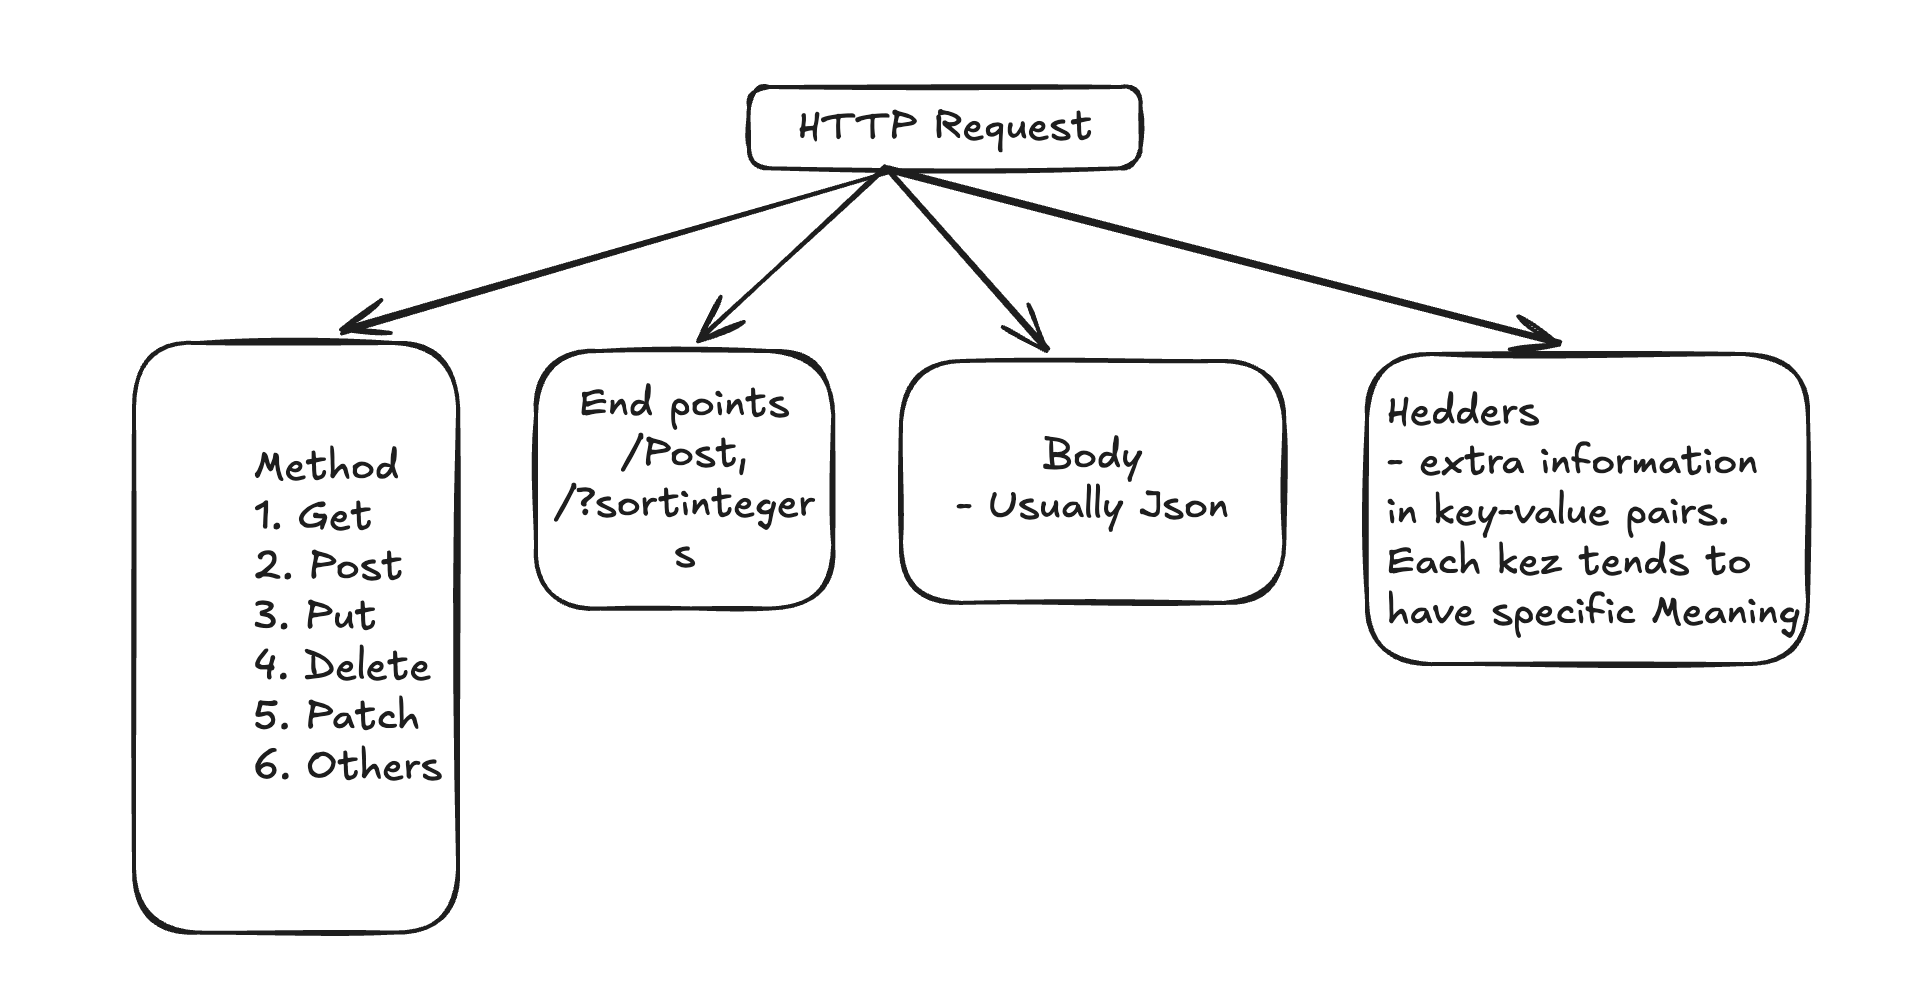

- Endpoint: where the information is send to 
- Body: some extra information with the request
    - eg: in post, what to post (this information is in post)
- Hedders:
    - content type hedder
        - content type: what is the type of the content


## REST
- Architectural constrains
- constrains
    - use the concept of client and server
    - concept of resource
    - stateless
    - cacheable
    - uniform hypermedia-driven interface
    - if backend uses multiple servers, this should be invisible to the client

## Resouce
- Thnks that the API deals with
    - posts, commnets, likes, users, etc
- when the client makes a requeest, it#s a request about a paritcular resounce
    - eg: give me the post with id 3
- when the server responds to a request, it does so with a resouce representation
    - eg:
    ```python
    {
        "id": 1123,
        "title": "post title here"
        "body": "bondz of the post here"
        "user_id": 3
    }
    ```

    ## Stateless
    - The server doesn't keep any information about the client
    - example, let say the client want to:
        - get information about post with id 3
        - change th post's title
    - This shoul dbe two requests (one GET and one PATCH)
    - in both the requests, the client must say what post it's talking bout
    - For the second request, the server can't remember that the first request was about post 3

    ## Cashable
    - if one client makes a request for information, it should be possible for the backend to save that response
    - if another client makes the request for same information, id doesn't need to be calculated

    ## Hypermedia driven
    - if a resource is related to another, then thers should be a acutal link in the response which allows the client to find the related resouce

    ```python
    "id": 123,
    "title": "post title here",
    "body": "post body here"
    "user_id": 3, 
    "user_link": "/user/3" # end ponint for user information
    ```
    - client can make a reques to the end point with user_id to get information about the user (hypermedia-driven)

    ## Multiple servers
    - Backend are made up of multiple severs
    - one for authentication, one for posts and gets
    - client shouldn't care about how the backend is organized


## Fast API

- structure of FastAPI
```python
from fastapi import FastAPI

app = FastAPI()

@app.get("/")
async def root():
    return("message": "Hello, World")
```


## Linting, formatting and sorting imports

- ruff
- ruff extention for vscode
- configuration
    - settings.json
    - ```
    {
        "[python]":{
                "editor.codeActionsOnSave":{
                "source.organizeImports": "explicit"
                "source.fixAll": true
            }
        },
        editor.formatOnSave": true,
        "editor.defaultFormatter": "charliermars.ruff",
    }
    
    ```


## Testing
- conftest.py
    - configure test
    - share data between various tests

``` python
from typing import AsyncGenerator, Generator

import pytest
from fastapi.testclient import TestClient #mock the client
# run test without starting the fast api client
from httpx import AsyncClient # to make request to client
```

- now need to gernerate a test client of the app
``` python
@pytest.fixture()
def client() -> Generator:
    yield TestClient(app)
```

- need to clear tables before the tests
- comment_table, post_table

```python
@pytest.fixture(autouse=True)
async def db(): -> AsyncGenerator:
    post_table.clear()
    comment_table.clear()
    yield
```
- fixture to share the fuction between tests
- autouse=True; every test will use this fixture


- now need a mechanism to make request to the client using http
```python
@pytest.fixture()
async def async_client(client) -> AsyncGenerator:
    transport = ASGITransport(app=app)
    async with AsyncClient(transport=transport, base_url=client.base_url) as ac:
        yield ac
```

## Error codes
- 422: pydantic validation error

## Working with DBs
- Databases
    - Executing queries
        - `SELECT * FROM posts WHERE id = 3`
    - Using an ORM
        - `Post.get(3)`

    - encode/databases Library
        - Async lib (since the FastAPI is an async lib)
        - Uses SQLAlchemy in the background
        - libs (dependencies)
            - sqkalchemy
            - databaes[aiosqllite]/databaes[asyncpg]
                - [asyncpg]: to talk to postgres database

    - database integration
        - database connection string
            - database location
            - username
            - password
            - etc

### Enviornment variable
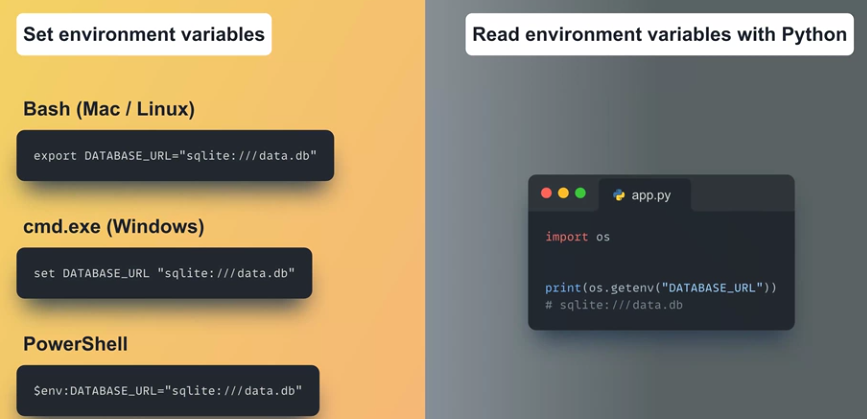

- .env file
    - `python-dotenv` library

- pydantic config file

```python
from pydantic import BaseSettings
from typing import Optional

class BaseConfig(BaseSettings):
    class Config:
        env_file = ".env"
        env_file_encoding = "utf-8"

class GlobalConfig(BaseConfig):
    DATABASE_URL: Optional[str] = None
    DB_FORECE_ROLL_BACK: bool = False
```


